# Marker-subset and lineage-removal training

**Role:** Training.

Fit and evaluate GINs on explicitly named subsets of the full marker panel, sharing organoid splits and target preprocessing. The subset dictionary can represent retained lineages, leave-one-lineage-out panels, or single-marker controls. Comparisons across depths use the same held-out organoids. Models, full raw fates, selected feature order, transformations and validation results are saved for later marker-subset analyses.

The current configuration belongs to the exclusive aligned-lineage paper study. All-cell and retained-lineage-only physical-unit MSE/MAE, and legacy budded-region plots, are evaluated in the separate paper notebooks. Original identities are retained for evaluation even when their input channels are omitted.

Conservative execution: ACTIVE_FOLDS and ACTIVE_MODELS can select a single fold/model per process, and RESUME_RUN continues the same catalog. Each reduced dataset is created on demand; its model and results are saved immediately, then the model and reduced dataset are released. The sequential launcher exits the worker after every model, also releasing the shared full-marker cohort and CUDA context. The complete marker is written only when every requested checkpoint exists.

In [ ]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/models/gnn.py").is_file())  # Locate the repository from the notebook’s working directory.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ROOT = PROJECT_ROOT  # Repository root used to resolve data and result paths.

## Configuration

Choose cohort filters, feature encoding, model grids and output location. A single holdout is selected with `n_folds=1`; larger values create disjoint outer validation folds. Outer validation also selects epochs, so these are validation estimates, not independent test errors.

`marker_subsets` maps each comparison label to the markers retained for that model. Supply any number of combinations; `None` means all markers. All combinations share the same folds and target preprocessing.

In [ ]:
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import attach_metadata_to_graphs, load_aux_metadata_for_dir, load_marker_names_from_dir
from src.data.filters import (filter_graphs_by_blacklist, load_graph_blacklist_from_dir,
    filter_graphs_by_timepoints, filter_graphs_by_sphericity, filter_graphs_by_numeric_metadata)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors
from src.data.marker_exclusivity import exclusive_markers, EXCLUSIVITY_RULES
from src.training.preparation import prepare_fold, select_marker_inputs, load_matching_fold
from src.models.gnn import GINCurvature
from src.models.size_models import seed_all
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term
from src.inference.predict import predict_targets
from src.artifacts.bundle import save_bundle, load_bundle, graph_membership
from src.artifacts.provenance import workflow_fingerprint
from src.artifacts.paths import training_run_path
from src.analysis.metrics.evaluation import compare_baseline_mse
from src.training.progress import TrainingProgress
from src.artifacts.runs import AnalysisRun


In [ ]:
# Execution switches
RUN_TRAINING = True  # Enable fitting and saving new model checkpoints.

SETTINGS = dict(
    # Run identity
    tag='paper_exclusive_20261006_153255',  # Optional purpose label; letters, digits, underscores and hyphens.

    # Dataset and targets
    dataset='after_cleanup',  # Source dataset folder under training_data/.
    target_indices=[0],  # Target columns to predict; [0] selects Gaussian curvature.

    # Data filters
    timepoints=['day4', 'day4p5', 'day4p5-more'],  # Shared cohort timepoints for train/validation; None keeps all, or use a list of labels.
    blacklist=True,  # Exclude organoids listed in the dataset blacklist.
    sphericity_max=0.94,  # Maximum retained sphericity; None disables this filter where supported.
    complexity_min=None,  # Minimum retained complexity; None disables this filter.
    interpolate_outliers=True,  # Replace extreme targets using neighboring cells.
    outlier_quantiles=[0.005, 0.995],  # Lower and upper quantiles defining target outliers.

    # Fate encoding
    exclusive_markers=True,  # Apply ordered rules so each cell has at most one fate.

    # Model grid
    depths=[2],  # GNN message-passing depths or control-model ring radii.
    hidden_dims=[128],  # Hidden widths to compare in the model grid.
    seeds=[42],  # Model initialization and training seeds to compare.

    # Data splits
    n_folds=5,  # n_folds=1: single holdout; larger values: organoid folds.
    val_fraction=0.2,  # Fraction of organoids held out when n_folds=1.
    split_seed=42,  # Random seed for organoid train/validation membership.

    # Target residualization
    residualize=False,  # Subtract the always-trained baseline from targets; False keeps original targets.
    baseline_features=['log_num_cells', 'log_surface_area', 'log_volume', 'log_volume_over_area'],  # Global features used only by the baseline model.

    # Model parameters
    global_features=['log_num_cells', 'log_surface_area', 'log_volume', 'log_volume_over_area'],  # Global columns appended to the prediction head.
    dropout=0.1,  # Probability of hidden-feature dropout during training.
    norm='batch',  # Hidden normalization: batch, layer, or none.
    residual=True,  # Enable residual connections within the GNN.

    # Training hyperparameters
    lr=0.0003,  # Optimizer learning rate.
    weight_decay=0.0001,  # AdamW weight-decay coefficient.
    batch_size=128,  # Number of graphs or subgraphs per batch.
    max_epochs=500,  # Maximum optimization epochs per fitted model.
    patience=30,  # Early-stopping patience, in epochs.
    num_workers=0,  # DataLoader worker processes; 0 loads in the main process.
    loss_name='gaussian',  # Prediction loss; gaussian fits a mean and uncertainty.

    # Training loss
    edge_loss_weight=0.2,  # Weight of the auxiliary edge-consistency penalty.
    edge_loss_params=dict(
        weighted=False,  # Weight edge penalties by the target difference.
        alpha=2.,  # Exponent controlling edge-loss weights.
        normalize_by='graph_std',  # Scale used to normalize the edge penalty.
        clip_weight=4.,  # Maximum weight assigned to one edge penalty.
    ),  # Options for computing the auxiliary edge penalty.

    # Baseline training
    baseline_hidden_dim=64,  # Hidden width of the global-only baseline.
    baseline_max_epochs=2000,  # Maximum training epochs for the global baseline.
    baseline_patience=30,  # Baseline early-stopping patience, in epochs.

    subset_depths={'LGR5': [0, 1, 2, 3, 4]},  # Override depths for selected subsets; other subsets use depths above.

    # Model and marker controls
    marker_subsets={
        'AldoB': ['AldoB'],  # Retained input markers; every cell remains a training target.
        'LGR5': ['LGR5'],  # Retained input markers; every cell remains a training target.
        'KI67': ['KI67'],  # Retained input markers; every cell remains a training target.
        'EXO': ['Agr2', 'Lysozyme'],  # Retained input markers; every cell remains a training target.
        'ENDO': ['Chroma', 'Serotonin'],  # Retained input markers; every cell remains a training target.
        'LGR5_AldoB': ['LGR5', 'AldoB'],  # Retained input markers; every cell remains a training target.
        'AldoB_KI67': ['AldoB', 'KI67'],  # Retained input markers; every cell remains a training target.
        'LGR5_ENDO': ['LGR5', 'Serotonin', 'Chroma'],  # Retained input markers; every cell remains a training target.
        'LGR5_EXO': ['LGR5', 'Lysozyme', 'Agr2'],  # Retained input markers; every cell remains a training target.
        'AldoB_EXO_ENDO': ['AldoB', 'Lysozyme', 'Agr2', 'Serotonin', 'Chroma'],  # Retained input markers; every cell remains a training target.
        'LGR5_EXO_ENDO': ['LGR5', 'Lysozyme', 'Agr2', 'Serotonin', 'Chroma'],  # Retained input markers; every cell remains a training target.
        'AldoB_KI67_EXO_ENDO': ['AldoB', 'KI67', 'Lysozyme', 'Agr2', 'Serotonin', 'Chroma'],  # Retained input markers; every cell remains a training target.
    },  # Named retained-marker panels; None selects all markers.
)  # Explicit run configuration, saved alongside the models.

# Training hyperparameters
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Use CUDA when available, otherwise CPU.

# Shared fitted preprocessing
PREPROCESSING_RUN = '/home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/gin_depth_training/paper_exclusive_20261006_153255_20261006_153321'  # Set by the study runner to its completed main run; None fits fresh preprocessing.

# Bounded execution and resume
ACTIVE_FOLDS = None  # None runs all folds; [0] runs just fold 0 in this process.
ACTIVE_MODELS = None  # None runs the grid; a list of model keys limits this process.
RESUME_RUN = None  # Existing run directory; complete checkpoints are reused.
RUN_REGIONAL_EVALUATION = False  # Paper regional evaluation is in the separate analysis notebook.

# Paths and outputs
RUN_DIR = Path(RESUME_RUN) if RESUME_RUN else training_run_path(ROOT, 'lineage_removal_training', SETTINGS['tag'])  # New run under training_results/<notebook>/<tag>_<timestamp>.
# Edit marker_subsets above to specify any named retained-marker combinations.

# Regional evaluation (annotations only; never model inputs)
REGION_SETTINGS = dict(
    crypt_max=.8,  # Crypt body: nearest normalized distance s < this boundary.
    neck_max=1.2,  # Qualified neck: crypt_max <= s <= neck_max; beyond is the villus proxy.
    neck_config=dict(
        minimum_crypt_cells=10,  # Assigned cells within s <= 1 required per crypt.
        minimum_relative_depth=.05,  # Minimum circumference trough depth relative to C(1).
        plateau_max_range=.10,  # Maximum relative circumference variation for a flat section.
        plateau_max_slope=.25,  # Maximum absolute relative slope of a flat section.
        plateau_exit_rise=.10,  # Required circumference rise after a flat section.
    ),
)

# Progress display
SHOW_PROGRESS = True  # Show one persistent panel for models, epochs and completed tasks.
PRINT_EPOCHS = False  # Also print each epoch; False keeps the training output compact.


## Load and filter the cohort

Attach metadata and retain requested organoids. Optional outlier interpolation follows the existing cohort-level preprocessing; its fitted information is saved. Marker exclusivity changes only fate channels and preserves unassigned cells and graph topology.
Each active organoid filter prints kept/total counts and the retained fraction for each dataset and timepoint. Counts refer to the cohort entering that step, after any preceding filters.


In [ ]:
data_dir = ROOT/'training_data'/SETTINGS['dataset']  # Dataset directory supplying graphs and metadata.
graphs = load_graph_dataset_from_dir(str(data_dir))
attach_metadata_to_graphs(graphs, load_aux_metadata_for_dir(str(data_dir)), exclude_keys=None)
graphs = filter_graphs_by_timepoints(graphs, SETTINGS['timepoints'], print_summary=True)
graphs = select_graph_targets(graphs, target_indices=SETTINGS['target_indices'], inplace=False)
marker_names = load_marker_names_from_dir(str(data_dir))
if not marker_names or SETTINGS['target_indices'] != [0]:
    raise ValueError('This workflow requires named fate channels and scalar Gaussian curvature.')
if SETTINGS['blacklist']:
    graphs = filter_graphs_by_blacklist(graphs, load_graph_blacklist_from_dir(data_dir), print_summary=True)
if SETTINGS['sphericity_max'] is not None:
    graphs = filter_graphs_by_sphericity(graphs, max_sphericity=SETTINGS['sphericity_max'], print_summary=True)
if SETTINGS['complexity_min'] is not None:
    graphs = filter_graphs_by_numeric_metadata(graphs, key='complexity', min_value=SETTINGS['complexity_min'], allow_missing=False, print_summary=True)
if SETTINGS['exclusive_markers']:
    for g in graphs:
        g.x = torch.as_tensor(exclusive_markers(g.x.cpu().numpy(), marker_names), dtype=g.x.dtype)
if SETTINGS['interpolate_outliers']:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(graphs, clip_quantiles=SETTINGS['outlier_quantiles'])
else:
    outlier_info = None
assert len(graphs) >= 2 and len({g.organoid_str for g in graphs}) == len(graphs)
cohort = pd.DataFrame([dict(organoid_str=g.organoid_str, n_cells=len(g.x),
                          timepoint=str(g.meta.get('timepoint', 'unknown'))) for g in graphs])
display(cohort.groupby('timepoint').agg(organoids=('organoid_str','size'), median_N=('n_cells','median')))


## Organism-level splits

Partition the cohort already selected by the shared `timepoints` setting. Training and validation draw from the same allowed timepoints; no organoid can enter both partitions. Display fold membership counts by timepoint before fitting.

In [ ]:
rng = np.random.default_rng(SETTINGS['split_seed'])
order = rng.permutation(len(graphs))
fold_count = SETTINGS['n_folds']
if not 1 <= fold_count <= len(graphs):
    raise ValueError('Invalid number of folds')
if fold_count == 1:
    if not 0 < SETTINGS['val_fraction'] < 1:
        raise ValueError('Invalid validation fraction')
    val_sets = [order[:max(1, min(len(order)-1, round(len(order)*SETTINGS['val_fraction'])))]]
else:
    val_sets = np.array_split(order, fold_count)
splits = []
for fold, val in enumerate(val_sets):
    split = dict(fold=fold, train_indices=np.setdiff1d(order, val).tolist(),
                 val_indices=val.tolist())
    if not split['train_indices'] or not split['val_indices']:
        raise ValueError(f'Empty cohort split: fold {fold}')
    splits.append(split)
membership = [dict(fold=s['fold'], **graph_membership(
    train=[graphs[i] for i in s['train_indices']], validation=[graphs[i] for i in s['val_indices']])) for s in splits]
display(pd.DataFrame([dict(fold=s['fold'], role=role, timepoint=cohort.iloc[i].timepoint)
    for s in splits for role in ('train', 'val') for i in s[role + '_indices']])
    .groupby(['fold', 'role', 'timepoint']).size().rename('organoids').to_frame())
# Only the job descriptions are collected; reduced datasets are created on demand.
model_jobs = [dict(key=f"gin_{subset}_intact_d{depth}_h{width}_f{split['fold']}_s{seed}",
                  subset=subset, depth=depth, hidden_dim=width, fold=split['fold'], seed=seed)
              for split in splits for subset in SETTINGS['marker_subsets']
              for depth in SETTINGS['subset_depths'].get(subset, SETTINGS['depths'])
              for width in SETTINGS['hidden_dims'] for seed in SETTINGS['seeds']]
if ACTIVE_MODELS is not None and (not ACTIVE_MODELS or not set(ACTIVE_MODELS) <= {job['key'] for job in model_jobs}):
    raise ValueError('ACTIVE_MODELS contains no models or unknown model keys.')
print(f'{len(model_jobs)} models in the full grid; only one reduced dataset is built at a time.')


## Fit, evaluate and save one model at a time

Reuse the reference fold's exact saved baseline, transformations, and ordered train/validation membership after checking cohort equality. Without a reference, fit preprocessing on that fold's training graphs. Create only the selected subset's input channels, fit the GIN, evaluate, and save before releasing the model and reduced dataset. All cells remain training targets; retained-lineage validation uses original exclusive identities, never the reduced input vector.

The launcher runs each subset/depth/fold in a fresh, memory-limited process. Completed checkpoints are skipped; a checkpoint saved before a bookkeeping interruption can be recovered without retraining. Per-model logs preserve optimization progress. The run is marked complete only after all requested models are catalogued.


In [ ]:
if not RUN_TRAINING:
    raise RuntimeError('Review settings, then set RUN_TRAINING=True to fit and save a new run.')
RUN_DIR.mkdir(parents=True, exist_ok=True)
SETTINGS['preprocessing_run'] = str(PREPROCESSING_RUN) if PREPROCESSING_RUN else None
if (RUN_DIR/'settings.json').exists() and json.loads((RUN_DIR/'settings.json').read_text()) != json.loads(json.dumps(SETTINGS)):
    raise ValueError('Resume settings differ from this saved run.')
(RUN_DIR/'settings.json').write_text(json.dumps(SETTINGS, indent=2))
(RUN_DIR/'splits.json').write_text(json.dumps(membership, indent=2))
(RUN_DIR/'exclusivity_rules.json').write_text(json.dumps(EXCLUSIVITY_RULES, indent=2))
cohort.to_csv(RUN_DIR/'cohort.csv', index=False)
provenance = workflow_fingerprint(ROOT/'experiments/training/lineage_removal_training.ipynb')
(RUN_DIR/'provenance.json').write_text(json.dumps({'code_sha256':provenance,'device':DEVICE}, indent=2))
if not (RUN_DIR/'cohort/manifest.json').exists():
    save_bundle(RUN_DIR/'cohort', dict(raw_graphs={g.organoid_str:g for g in graphs},
        all_marker_names=marker_names, settings=SETTINGS, outlier_info=outlier_info),
        splits=membership, provenance={'code_sha256':provenance})
records = json.loads((RUN_DIR/'models.json').read_text()) if (RUN_DIR/'models.json').exists() else []
scores = pd.read_csv(RUN_DIR/'validation_mse.csv').to_dict('records') if (RUN_DIR/'validation_mse.csv').exists() else []
baseline_rows = pd.read_csv(RUN_DIR/'baseline_validation_mse.csv').to_dict('records') if (RUN_DIR/'baseline_validation_mse.csv').exists() else []
completed_keys = {r['key'] for r in records}
raw_by_org = {g.organoid_str: g for g in graphs}  # Original identities for retained-cell evaluation.
for record in records:
    saved_rows = [row for row in scores if row['key'] == record['key']]
    expected_orgs = set(membership[record['fold']]['validation'])
    if {row['organoid_str'] for row in saved_rows} != expected_orgs:
        raise ValueError(f"Incomplete saved validation rows for {record['key']}; recover before resuming.")
active_splits = [s for s in splits if ACTIVE_FOLDS is None or s['fold'] in ACTIVE_FOLDS]
if not active_splits:
    raise ValueError('No folds selected.')
active_jobs = [job for job in model_jobs if job['fold'] in {s['fold'] for s in active_splits}
               and (ACTIVE_MODELS is None or job['key'] in ACTIVE_MODELS)
               and job['key'] not in completed_keys]
with TrainingProgress(len(active_jobs), total_baselines=len({job['fold'] for job in active_jobs}),
                      show=SHOW_PROGRESS, print_epochs=PRINT_EPOCHS,
                      log_path=RUN_DIR/'logs'/('progress_' + (ACTIVE_MODELS[0] if ACTIVE_MODELS and len(ACTIVE_MODELS)==1 else 'grid') + '.csv')) as progress:
    for split in active_splits:
        fold_jobs = [job for job in active_jobs if job['fold'] == split['fold']]
        if not fold_jobs:
            continue
        seed_all(SETTINGS['split_seed'] + split['fold'])
        with progress.task(kind='baseline', model='Global baseline', fold=split['fold']):
            if PREPROCESSING_RUN is not None:
                prepared = load_matching_fold(PREPROCESSING_RUN, SETTINGS, graphs, membership, split['fold'])
            else:
                prepared = prepare_fold(graphs, split, global_features=SETTINGS['global_features'],
                    residualize=SETTINGS['residualize'], baseline_features=SETTINGS['baseline_features'],
                    baseline_kwargs=dict(hidden_dim=SETTINGS['baseline_hidden_dim'], max_epochs=SETTINGS['baseline_max_epochs'],
                        patience=SETTINGS['baseline_patience'], batch_size=SETTINGS['batch_size'], num_workers=SETTINGS['num_workers'],
                        train_kwargs=dict(device=DEVICE)))
        baseline_rows = [r for r in baseline_rows if r['fold'] != split['fold']]
        baseline_rows.extend(dict(fold=split['fold'], **row) for row in prepared['baseline_validation_mse'])
        pd.DataFrame(baseline_rows).to_csv(RUN_DIR/'baseline_validation_mse.csv', index=False)
        for subset_name, selection in SETTINGS['marker_subsets'].items():
            subset_jobs = {job['key'] for job in fold_jobs if job['subset'] == subset_name}
            if not subset_jobs:
                continue
            selected = marker_names if selection is None else list(selection)
            if not selected or not set(selected) <= set(marker_names):
                raise ValueError(f'Invalid marker subset {subset_name}: {selected}')
            subset_groups = select_marker_inputs(prepared['groups'], marker_names, selected)
            signal = 'intact'
            groups = subset_groups
            input_bundle = f"inputs/fold_{split['fold']}_{subset_name}_{signal}"
            prepared_inputs = {k:v for k,v in prepared.items() if k != 'groups'}
            prepared_inputs.update(groups=groups, marker_names=selected)
            if not (RUN_DIR/input_bundle/'manifest.json').exists():
                save_bundle(RUN_DIR/input_bundle, prepared_inputs, splits=membership[split['fold']],
                            provenance={'code_sha256':provenance})
            for depth in SETTINGS['subset_depths'].get(subset_name, SETTINGS['depths']):
                for width in SETTINGS['hidden_dims']:
                    for seed in SETTINGS['seeds']:
                        key = f"gin_{subset_name}_intact_d{depth}_h{width}_f{split['fold']}_s{seed}"
                        if key not in subset_jobs:
                            continue
                        with progress.task(model='gin', subset=subset_name, signal='intact', depth=depth, width=width, fold=split['fold'], seed=seed):
                            family = 'gin'
                            seed_all(seed)
                            kw = dict(n_markers=len(selected), hidden_dim=width, dropout=SETTINGS['dropout'],
                                      norm=SETTINGS['norm'], global_dim=len(SETTINGS['global_features']))
                            checkpoint = RUN_DIR/'models'/key
                            if (checkpoint/'manifest.json').exists():
                                # A checkpoint saved just before an interruption is reused, not refitted.
                                recovered = load_bundle(checkpoint)
                                model, metrics, history = (recovered[k] for k in ('model', 'metrics', 'history'))
                                del recovered
                            else:
                                model = GINCurvature(**kw, num_layers=depth, residual=SETTINGS['residual'])
                                cfg = TrainConfig(**{k:SETTINGS[k] for k in
                                    ['lr','weight_decay','batch_size','max_epochs','patience','num_workers','loss_name']},
                                    device=DEVICE, aux_losses=[WeightedLossTerm(name='edge', fn=edge_loss_term,
                                    weight=SETTINGS['edge_loss_weight'], params=SETTINGS['edge_loss_params'])])
                                model, metrics, history = train(model, groups['train'], groups['val'], cfg)
                            key = f"{family}_{subset_name}_{signal}_d{depth}_h{width}_f{split['fold']}_s{seed}"
                            record = dict(key=key, name=family, subset=subset_name, signal=signal, depth=depth,
                                          hidden_dim=width, fold=split['fold'], seed=seed, bundle=f'models/{key}', input_bundle=input_bundle)
                            progress.stage('Evaluating held-out predictions and saving checkpoint')
                            y, mu, _ = predict_targets(groups['val'], model, target_transform=prepared['transform'], device=DEVICE)
                            start = 0
                            model_scores = []
                            selected_columns = [marker_names.index(name) for name in selected]
                            for g in groups['val']:
                                end = start + len(g.x)
                                truth = np.asarray(y)[start:end].reshape(-1)
                                prediction = np.asarray(mu)[start:end].reshape(-1)
                                error = prediction - truth
                                retained = raw_by_org[g.organoid_str].x[:, selected_columns].bool().any(dim=1).cpu().numpy()
                                physical_truth = truth + np.asarray(prepared['baseline_offsets'][g.organoid_str]).reshape(-1)
                                base_error = np.asarray(prepared['baseline_predictions'][g.organoid_str]).reshape(-1) - physical_truth
                                model_scores.append(dict(**record, organoid_str=g.organoid_str, n_cells=len(g.x),
                                    mse=float(np.mean(error**2)), mae=float(np.mean(np.abs(error))),
                                    retained_n_cells=int(retained.sum()),
                                    retained_mse=float(np.mean(error[retained]**2)) if retained.any() else np.nan,
                                    retained_mae=float(np.mean(np.abs(error[retained]))) if retained.any() else np.nan,
                                    retained_baseline_mse=float(np.mean(base_error[retained]**2)) if retained.any() else np.nan,
                                    retained_baseline_mae=float(np.mean(np.abs(base_error[retained]))) if retained.any() else np.nan))
                                start = end
                            if not (checkpoint/'manifest.json').exists():
                                save_bundle(checkpoint, dict(model=model.cpu(), record=record, history=history,
                                            metrics=metrics, validation_scores=model_scores),
                                            splits=membership[split['fold']], provenance={'code_sha256':provenance})
                            scores = [row for row in scores if row['key'] != key] + model_scores
                            # Publish metrics before cataloguing the checkpoint; orphan checkpoints can be recovered.
                            score_path = RUN_DIR/'validation_mse.csv'
                            score_tmp = score_path.with_suffix('.tmp')
                            compare_baseline_mse(scores, baseline_rows).to_csv(score_tmp, index=False)
                            score_tmp.replace(score_path)
                            records.append(record)
                            record_path = RUN_DIR/'models.json'
                            record_tmp = record_path.with_suffix('.tmp')
                            record_tmp.write_text(json.dumps(records, indent=2))
                            record_tmp.replace(record_path)
                            completed_keys.add(key)
                            del model, metrics, history, y, mu, model_scores
                            gc.collect()
                            if torch.cuda.is_available():
                                torch.cuda.empty_cache()
            # No reduced dataset or trained model survives into the next subset.
            del prepared_inputs, groups, subset_groups, g
            gc.collect()
        del prepared
        gc.collect()
    if len(records) == len(splits)*sum(len(SETTINGS['subset_depths'].get(k,SETTINGS['depths'])) for k in SETTINGS['marker_subsets'])*len(SETTINGS['hidden_dims'])*len(SETTINGS['seeds']):
        (RUN_DIR/'complete.json').write_text(json.dumps({'models':len(records)}))
    print('Saved run:', RUN_DIR)

## Saved validation results

Report completion without reloading every dataset. Per-organoid MSE and MAE are saved for all cells and for cells belonging to the retained lineages, including baseline errors evaluated on those same retained cells. The separate paper analysis notebook loads the trained artifacts for depth, subset, and legacy budded-crypt/neck figures in physical units.


Completed 80 models across five folds. Exact reference splits and saved-artifact hashes verified. Peak sequential worker memory: 2.61 GiB.
Saved run: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/lineage_removal_training/paper_exclusive_20261006_153255_20261007_113617
Full analysis: experiments/paper/depth_and_lineage_evaluation.ipynb


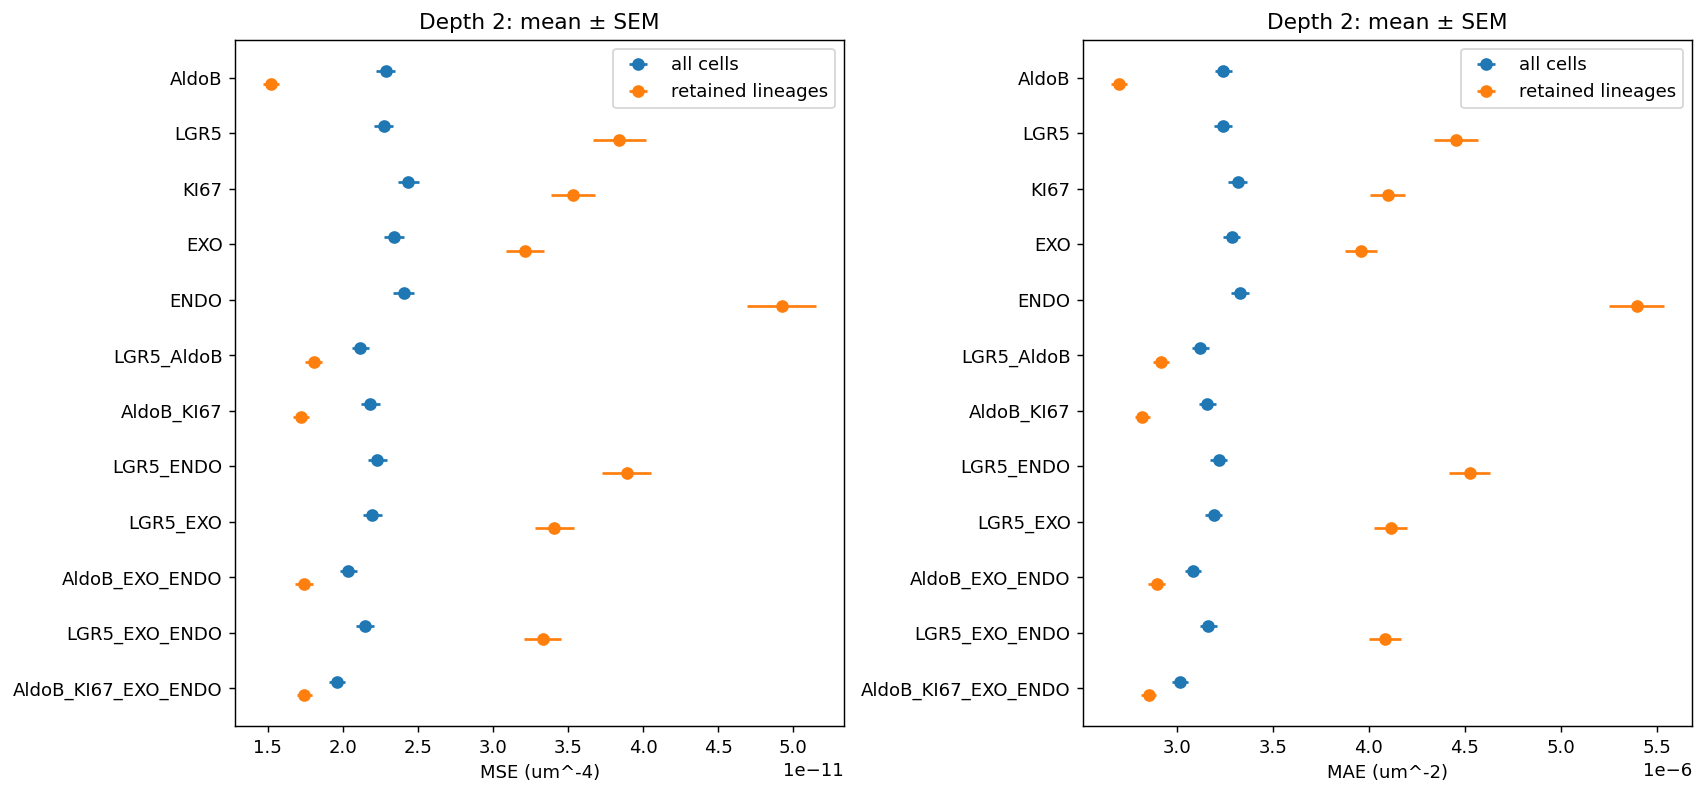

In [1]:
validation = pd.read_csv(RUN_DIR/'validation_mse.csv')
print(f"Saved {len(records)} checkpoints; complete={(RUN_DIR/'complete.json').exists()}")
print('All-cell and retained-lineage MSE/MAE are saved per organoid; original identities define retained cells.')
print('Physical-unit figures and regional comparisons are produced by the separate paper analysis notebook.')


## Validation MSE by anatomical region and model depth

Reopen every saved checkpoint and evaluate its validation cells with the saved inputs, target transform, and baseline. Regions are derived directly from the source dataset's `d_crypts_graph` and `proj_vertex_ids` arrays and the original segmentation file named in each organoid's metadata. No tables from another experiment are loaded. Annotation settings are near the top of this notebook.

Use the **original nearest crypt**, checked against segmentation distances at each cell's projected vertex. Its circumference must have a supported local minimum or flat section near s=1 and enough assigned cells. Within these qualified territories, s<0.8 is crypt body, 0.8≤s≤1.2 is neck, and s>1.2 is the operational villus distance proxy (thresholds are configurable). Cells are never reassigned from an unqualified crypt to a farther qualified one. Missing annotations, no detected crypts, and unqualified territories remain separate in the support and score tables, rather than being labelled villus. Small undetected crypts remain a limitation of the source annotations.

Each panel shows physical-curvature MSE against depth for all saved folds, with separate curves for model variants and a dashed global baseline. First average squared errors within each organoid/region, then average repeated seeds or validation appearances within each organoid. Shading is ±1 SEM across organoids, conditional on the fitted models. A single trained depth produces a single point; SEM is absent with fewer than two organoids. Masking models are evaluated with all fates observed. Model inputs and fitting are unchanged.

Save per-organoid MSE, node-aligned region assignments and their source paths, support counts, summaries, settings, and the figure under the training run's `regional_evaluation/` folder. This section can also be rerun on an existing `RUN_DIR` without retraining, after restoring imports, `DEVICE`, and `REGION_SETTINGS`.


In [ ]:
if RUN_REGIONAL_EVALUATION:
    from src.analysis.spatial.regions import graph_regions
    from src.analysis.metrics.evaluation import prediction_table, regional_mse
    from src.plotting.depth_scan import plot_regional_mse
    
    regional_run = AnalysisRun(RUN_DIR)
    region_dataset_name = (regional_run.settings['dataset'] if regional_run.modern
                           else regional_run.legacy.settings['DATASET_NAME'])
    region_data_dir = ROOT / 'training_data' / region_dataset_name
    region_output = RUN_DIR / 'regional_evaluation'
    region_output.mkdir(exist_ok=True)
    (region_output / 'settings.json').write_text(json.dumps(
        dict(dataset=str(region_data_dir), **REGION_SETTINGS), indent=2))
    region_annotations = {}
    region_score_parts = []
    for regional_record in regional_run.records.to_dict('records'):
        selected = regional_run.select(regional_record['key'], device=DEVICE)
        for graph in selected['groups']['val']:
            if graph.organoid_str not in region_annotations:
                raw_graph = selected['raw_graphs'][graph.organoid_str]
                region_annotations[graph.organoid_str] = graph_regions(raw_graph, region_data_dir, **REGION_SETTINGS)
        annotations = pd.concat([region_annotations[g.organoid_str] for g in selected['groups']['val']], ignore_index=True)
        predictions = prediction_table(selected, device=DEVICE)
        if 'baseline_squared_error' not in predictions:
            raise ValueError('Saved per-node baseline predictions are required for regional comparison.')
        regional_scores = regional_mse(predictions, annotations)
        for column in ('key', 'name', 'subset', 'signal', 'hidden_dim', 'depth', 'fold', 'seed', 'rate'):
            if column in regional_record:
                regional_scores[column] = regional_record[column]
        region_score_parts.append(regional_scores)
        del selected, predictions
    regional_scores = pd.concat(region_score_parts, ignore_index=True)
    regional_scores.to_csv(region_output / 'validation_mse.csv', index=False)
    annotations = pd.concat(region_annotations.values(), ignore_index=True)
    annotations.to_csv(region_output / 'node_regions.csv.gz', index=False)
    region_support = annotations.groupby(['region', 'annotation_status']).agg(
        organoids=('organoid_str', 'nunique'), cells=('node', 'size'))
    region_support.to_csv(region_output / 'annotation_support.csv')
    display(region_support)
    variant_columns = [c for c in ('name', 'subset', 'signal', 'hidden_dim', 'rate', 'depth', 'region') if c in regional_scores]
    regional_summary = organoid_mse_summary(regional_scores, variant_columns)
    regional_summary.to_csv(region_output / 'mse_summary.csv', index=False)
    regional_baseline_summary = organoid_mse_summary(regional_scores, ['depth', 'region'], value='baseline_mse')
    regional_baseline_summary.to_csv(region_output / 'baseline_mse_summary.csv', index=False)
    fig = plot_regional_mse(regional_scores)
    fig.savefig(region_output / 'mse_by_depth.png', dpi=160, bbox_inches='tight')
    plt.show()
else:
    print('Regional evaluation is delegated to the saved-model paper analysis notebook.')